In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Input, Activation, BatchNormalization,Dropout
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
import keras
from tensorflow.keras import layers, models

2025-03-18 15:33:23.595752: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [20]:
file_path = '../data/X_test.npy'
X_test = np.load(file_path)
file_path = '../data/y_test.npy'
y_test = np.load(file_path)
file_path = '../data/X_train.npy'
X_train = np.load(file_path)
file_path = '../data/y_train.npy'
y_train = np.load(file_path)
labels = ['SF', 'Comp', 'AGN', 'Liner']


In [23]:
#print out feature names from data file data_matched_step2.csv
features = ['O3_index', 'O2_index', 'sigma_star', 'sigma_o3', 'u_g', 'g_r', 'r_i', 'i_z']
#slice the data to only include the optical features
X_train = X_train[:, :4]
X_test = X_test[:, :4]
print(X_train.shape)
print(X_test.shape)

(4571, 4)
(1962, 4)


In [16]:
keras.backend.clear_session()
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train_split = scaler.transform(X_train_split)

X_val_split = scaler.transform(X_val_split)
X_test = scaler.transform(X_test)

p_dropout=0.5

keras.backend.clear_session()


inputs = layers.Input(shape=(4,))

fc1 = layers.Dense(512, name="fc1", kernel_regularizer=keras.regularizers.l2(0.05))(inputs)
fc1 = layers.Activation(activation="relu")(fc1)
fc1 = layers.Dropout(p_dropout)(fc1)
fc1 = layers.BatchNormalization(axis=-1)(fc1)

fc2 = layers.Dense(512, name="fc2", kernel_regularizer=keras.regularizers.l2(0.05))(fc1)
fc2 = layers.Activation(activation="relu")(fc2)
fc2 = layers.Dropout(p_dropout)(fc2)
fc2 = layers.BatchNormalization(axis=-1)(fc2)

skip_connection = fc1  # skip connection

combined_input = layers.Add()([fc2, skip_connection])
fc5 = layers.Dense(512, name="fc5", kernel_regularizer=keras.regularizers.l2(0.05))(combined_input)
fc5 = layers.Activation(activation="relu")(fc5)
fc5 = layers.Dropout(p_dropout)(fc5)
fc5 = layers.BatchNormalization(axis=-1)(fc5)

output = layers.Dense(4, activation='softmax')(fc5)

model = models.Model(inputs=inputs, outputs=output)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 512)       │      2,560 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512)       │          0 │ fc1[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dropout[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 512)       │    262,656 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512)       │          0 │ fc2[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dropout_1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512)       │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc5 (Dense)         │ (None, 512)       │    262,656 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 512)       │          0 │ fc5[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dropout_2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │      2,052 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 536,068 (2.04 MB)

 Trainable params: 532,996 (2.03 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [17]:
#implement changing learning rate
from tensorflow.keras.callbacks import LearningRateScheduler
import tensorflow as tf
from tensorflow.keras import backend as ops

def lr_schedule(epoch, lr):
    return 0.00001 if epoch >= 5 else 0.001

lr_callback = LearningRateScheduler(lr_schedule)

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

model_history = model.fit(X_train_split, y_train_split, epochs=15, batch_size=16, verbose=1, shuffle=True, validation_data=(X_val_split, y_val_split),callbacks=[lr_callback])

Epoch 1/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6566 - loss: 29.2419 - val_accuracy: 0.7246 - val_loss: 4.6920 - learning_rate: 0.0010
Epoch 2/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7648 - loss: 3.5635 - val_accuracy: 0.7934 - val_loss: 1.9680 - learning_rate: 0.0010
Epoch 3/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7774 - loss: 1.8916 - val_accuracy: 0.8186 - val_loss: 1.5196 - learning_rate: 0.0010
Epoch 4/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7829 - loss: 1.5924 - val_accuracy: 0.8131 - val_loss: 1.3874 - learning_rate: 0.0010
Epoch 5/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7752 - loss: 1.4143 - val_accuracy: 0.8120 - val_loss: 1.3578 - learning_rate: 0.0010
Epoch 6/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7970 - loss: 1.3983 - val_accuracy: 0.8219 - val_loss: 1.2819 - learning_rate: 1.0000e-05
Epoch 7/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7998 - los

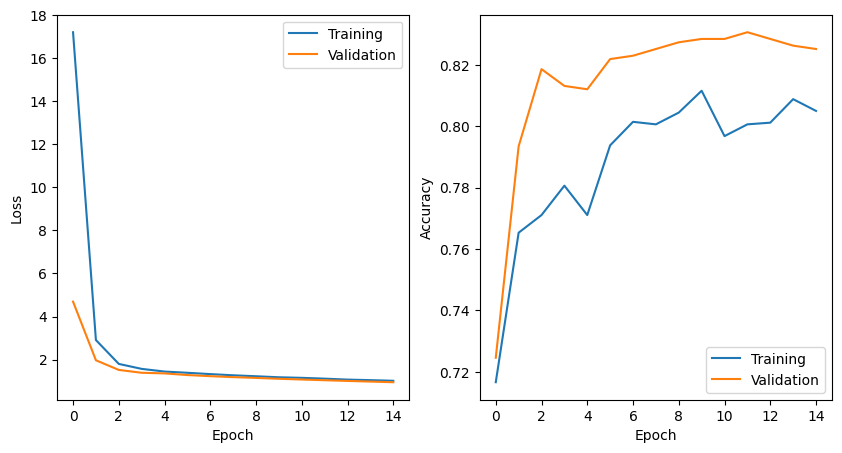

In [18]:
import sys
sys.path.append('..')
import plotting


plotting.plot_model_history(model_history)

pred = model.predict(X_test,verbose=0)

In [21]:
#calculate accuracy
from sklearn.metrics import accuracy_score
y_pred = np.argmax(pred, axis=1)
y_true = np.argmax(y_test, axis=1)
accuracy = accuracy_score(y_true, y_pred)
print("Overall accuracy: ", accuracy)

#calculate confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
#print(cm)

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(per_class_accuracy):
    print(f"Accuracy for class {labels[i]}: {acc:.4f} \n")

#calculate accuracy for each of the 4 classes
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=labels))

Overall accuracy:  0.8318042813455657
Accuracy for class SF: 0.9449 

Accuracy for class Comp: 0.6627 

Accuracy for class AGN: 0.7049 

Accuracy for class Liner: 0.6136 

              precision    recall  f1-score   support

          SF       0.90      0.94      0.92      1179
        Comp       0.70      0.66      0.68       424
         AGN       0.79      0.70      0.75       183
       Liner       0.65      0.61      0.63       176

    accuracy                           0.83      1962
   macro avg       0.76      0.73      0.75      1962
weighted avg       0.83      0.83      0.83      1962



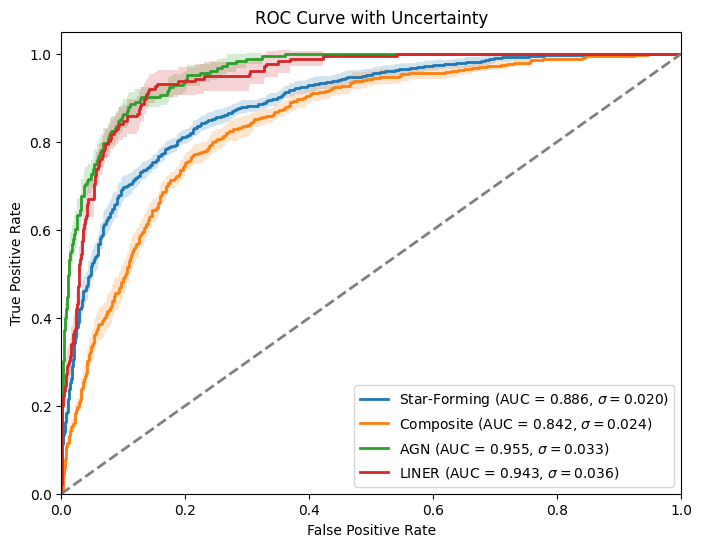

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

def monte_carlo_predictions(model, X, num_samples=50):
    """
    Performs Monte Carlo Dropout inference to estimate model uncertainty.
    """
    preds = np.array([model(X, training=True).numpy() for _ in range(num_samples)])  
    return preds 

num_mc_samples = 20
mc_preds = monte_carlo_predictions(model, X_test, num_mc_samples)

y_pred_prob = np.mean(mc_preds[:, :, :4], axis=0)
y_pred_uncertainty = np.std(mc_preds[:, :, :4], axis=0) 

fpr = {}
tpr = {}
roc_auc = {}
tpr_uncertainty = {}

for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    tpr_samples = []
    for j in range(num_mc_samples):
        fpr_sample, tpr_sample, _ = roc_curve(y_test[:, i], mc_preds[j, :, i])
        
        interp_func = interp1d(fpr_sample, tpr_sample, kind='linear', fill_value='extrapolate')
        tpr_samples.append(interp_func(fpr[i]))

    tpr_samples = np.array(tpr_samples)
    tpr_uncertainty[i] = np.std(tpr_samples, axis=0) 

plt.figure(figsize=(8, 6))
classes = ['Star-Forming', 'Composite', 'AGN', 'LINER']

for i in range(4):
    #check for nan values and remove them
    for n in tpr_uncertainty[i]:
        if np.isnan(n):
            tpr_uncertainty[i] = np.delete(tpr_uncertainty[i], np.where(np.isnan(tpr_uncertainty[i])))
            fpr[i] = np.delete(fpr[i], np.where(np.isnan(tpr_uncertainty[i])))
            tpr[i] = np.delete(tpr[i], np.where(np.isnan(tpr_uncertainty[i])))
            break
    plt.plot(fpr[i], tpr[i], lw=2, label=rf'{classes[i]} (AUC = {roc_auc[i]:.3f}, $\sigma = ${tpr_uncertainty[i].mean():.3f})')
    
    min_len = min(len(tpr[i]), len(tpr_uncertainty[i])) 
    plt.fill_between(
    fpr[i][:min_len], 
    tpr[i][:min_len] - tpr_uncertainty[i][:min_len],
    tpr[i][:min_len] + tpr_uncertainty[i][:min_len],  
    alpha=0.2)

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Uncertainty')
plt.legend(loc='lower right')
plt.savefig('../plots/NN-ROC_Curves.pdf', format='pdf')
plt.show()